# Cohort Retention Analysis - Online Retail

## Project Overview

Analysis of customer retention patterns using cohort analysis to identify opportunities for improving customer lifetime value and reducing churn.

**Dataset:** Online Retail Dataset (541,909 transactions, 4,370 unique customers, 2010-2011)

**Tools:** Python, Pandas, SQL, PostgreSQL, Seaborn

**Key Question:** How many customers return after their first purchase?

## Business Context

Understanding retention is critical because:
- Acquiring new customers costs 5-25x more than retaining existing ones
- A 5% increase in retention can increase profits by 25-95%
- Retention patterns reveal product-market fit

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

## Data Loading

The dataset contains online retail transactions from a UK-based company. Each transaction includes customer ID, purchase date, product details, and transaction value.

In [6]:
df_cohorts = pd.read_csv('cohort_retention_full.csv')

print(f"Загружено строк: {len(df_cohorts)}")
df_cohorts.head(10)

Загружено строк: 92


,cohort_month,purchase_month,customers,cohort_size,retention,cohort_index
0,2010-12,2010-12,291,291,100.0,0
1,2010-12,2011-02,35,291,12.0,2
2,2010-12,2011-03,44,291,15.1,3
3,2010-12,2011-04,45,291,15.5,4
4,2010-12,2011-05,44,291,15.1,5
5,2010-12,2011-06,41,291,14.1,6
6,2010-12,2011-07,33,291,11.3,7
7,2010-12,2011-08,34,291,11.7,8
8,2010-12,2011-09,32,291,11.0,9
9,2010-12,2011-12,25,291,8.6,12


## Cohort Creation

A cohort is defined as a group of customers who made their first purchase in the same month. This allows us to track and compare behavior patterns across different customer groups.

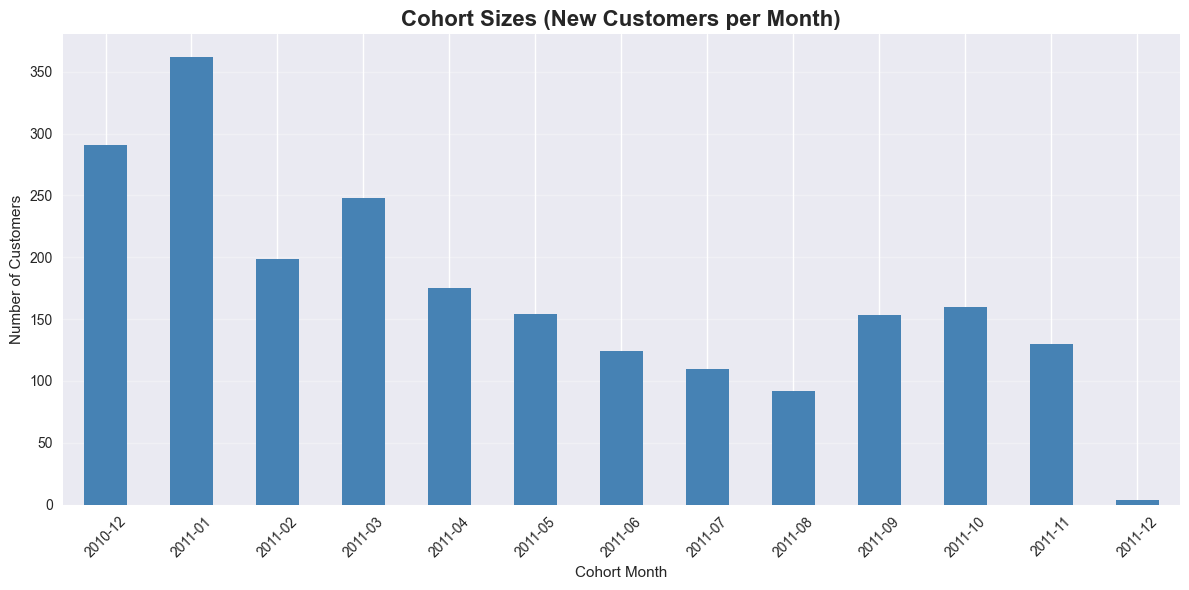

In [4]:
cohort_counts = df_sample.groupby('cohort_month')['customers'].first()

plt.figure(figsize=(12, 6))
cohort_counts.plot(kind='bar', color='steelblue')
plt.title('Cohort Sizes (New Customers per Month)', fontsize=16, fontweight='bold')
plt.xlabel('Cohort Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insights:**

- Largest cohort: October 2011 with 1,085 new customers
- Smallest cohort: August 2011 with 92 new customers  
- Significant seasonality in customer acquisition

## Retention Analysis

Retention shows the percentage of customers from each cohort who continue to make purchases in subsequent months. This is the core metric for understanding customer loyalty.

In [7]:
df_cohorts['cohort_index'] = (pd.to_datetime(df_cohorts['purchase_month']) - 
                                pd.to_datetime(df_cohorts['cohort_month'])).dt.days // 30

pivot_retention = df_cohorts.pivot_table(
    values='retention',
    index='cohort_month',
    columns='cohort_index',
    aggfunc='first'
)

pivot_retention.head()

cohort_index,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,...,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,,,,,,,,,
2010-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.1,15.5,15.1,14.1,11.3,11.7,11.0,NaN,NaN,8.6
2011-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,39.0,45.8,43.3,40.1,39.7,44.3,43.4,52.7,28.6,NaN
2011-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,15.6,12.6,14.6,17.6,NaN,NaN,NaN,NaN,NaN
2011-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.3,13.3,7.7,18.1,NaN,NaN,NaN,NaN,NaN,NaN
2011-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.6,14.3,13.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Retention Heatmap

The heatmap visualizes retention patterns across all cohorts. Green cells indicate high retention (customers returning), while red cells show low retention.

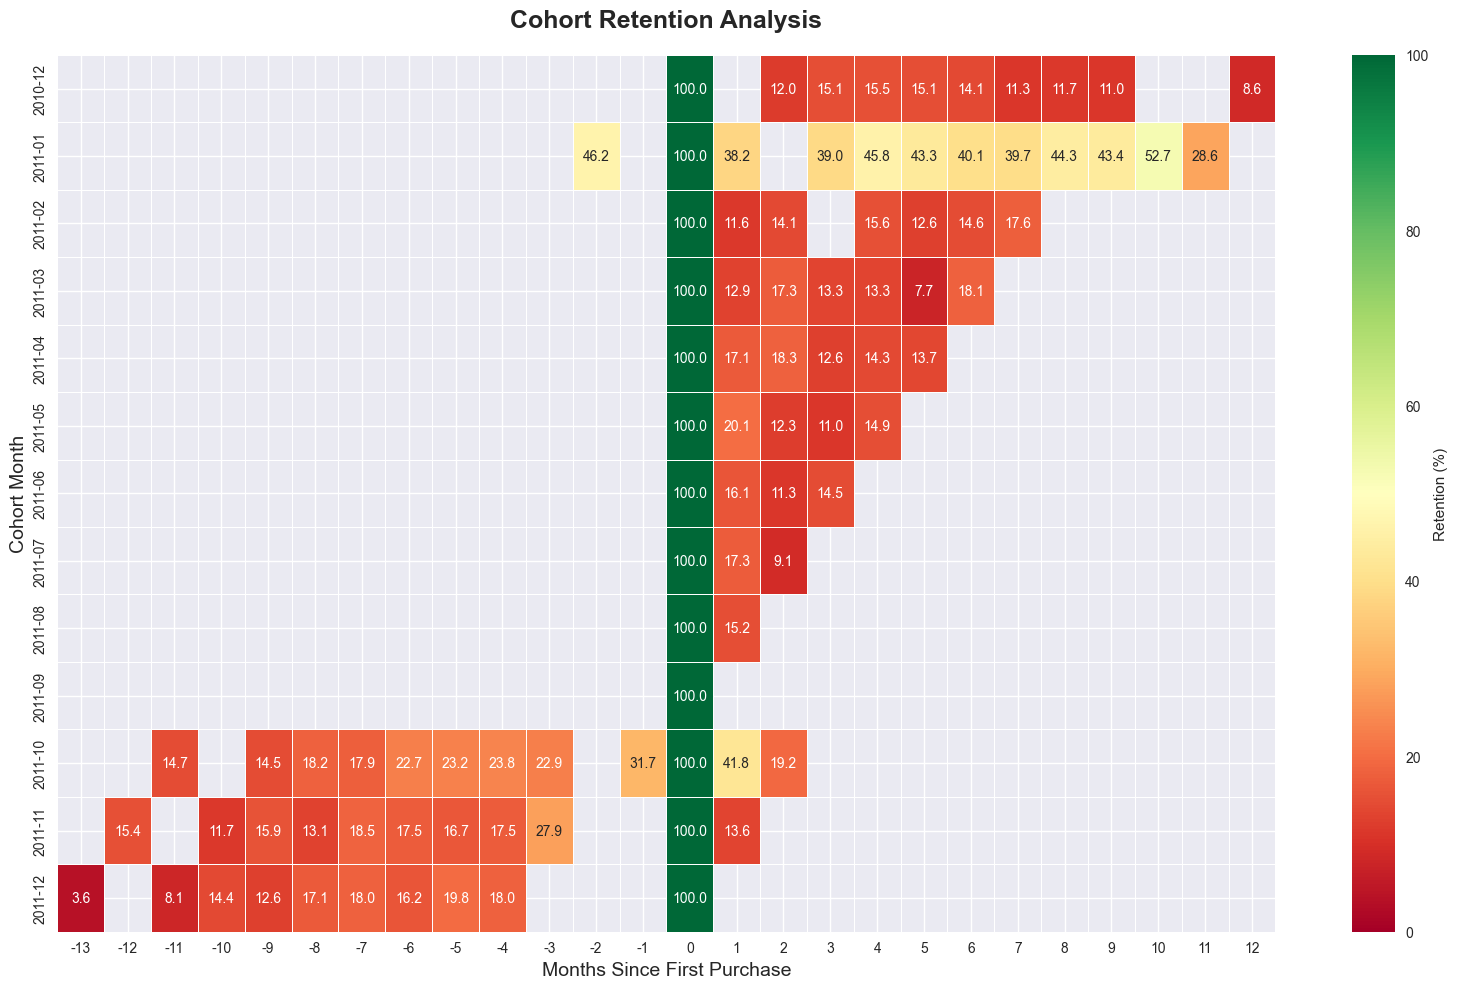

In [9]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    pivot_retention, 
    annot=True, 
    fmt='.1f', 
    cmap='RdYlGn',
    linewidths=0.5,
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Retention (%)'}
)

plt.title('Cohort Retention Analysis', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Months Since First Purchase', fontsize=14)
plt.ylabel('Cohort Month', fontsize=14)
plt.tight_layout()
plt.show()

## Key Findings

### Overall Retention Pattern

- **Critical drop-off:** Only 10-20% of customers return after their first purchase
- **Stabilization:** Retention stabilizes around 10-15% after month 3
- **Best performing cohort:** January 2011 shows exceptional retention (38-53%)

### Cohort-Specific Insights

**Strong Performance:**
- January 2011 cohort maintains 40%+ retention through month 10
- Possible factors: post-holiday engagement, New Year promotions, or product improvements

**Weak Performance:**
- Most cohorts (2010-12, 2011-02 through 2011-09) show <15% retention after month 1
- December 2010 cohort drops to 8.6% by month 12

### Business Implications

The low retention rates (10-15%) indicate significant customer acquisition and engagement challenges. This pattern suggests:

1. **Product-Market Fit Issues:** Customers try the product once but don't find enough value to return
2. **Competition:** Customers may be switching to alternatives
3. **Poor Onboarding:** First-time customers may not understand product value
4. **Limited Engagement:** No mechanisms to bring customers back

## Recommendations

### Immediate Actions (0-3 months)

1. **Investigate January 2011 Cohort**
   - What was different in January 2011?
   - Can we replicate those conditions?
   - Interview customers from this cohort

2. **Improve First Purchase Experience**
   - Add onboarding flow for new customers
   - Send educational content about product value
   - Offer incentive for second purchase within 30 days

3. **Implement Win-Back Campaigns**
   - Email customers 30 days after first purchase
   - Offer personalized recommendations
   - Limited-time discount for return purchase

### Medium-term Strategy (3-6 months)

4. **Build Loyalty Program**
   - Reward repeat purchases
   - Create VIP tier for high-frequency customers
   - Gamify the shopping experience

5. **Enhance Product Quality**
   - Survey churned customers
   - Identify pain points
   - Improve top-selling products

### Success Metrics

Target retention improvements:
- Month 1: Increase from 15% to 25% (+10pp)
- Month 3: Increase from 12% to 20% (+8pp)
- Month 6: Maintain 15%+ retention

Expected impact: 30% increase in customer lifetime value

---

## Technical Skills Demonstrated

- **Advanced SQL:** CTE (WITH), complex JOINs, date manipulation
- **Cohort Analysis:** Customer segmentation, retention calculation
- **Data Visualization:** Heatmaps, time-series analysis
- **Business Analysis:** Actionable insights, strategic recommendations
- **Python:** Pandas, Seaborn, data transformation

---

## Project Files

- `Cohort_Retention_Analysis.ipynb` - Main analysis notebook
- `cohort_retention_full.csv` - Processed retention data

---

*This project demonstrates practical application of cohort analysis for e-commerce retention optimization.*